#### Logistic Regression

Regularized Logistic Regression

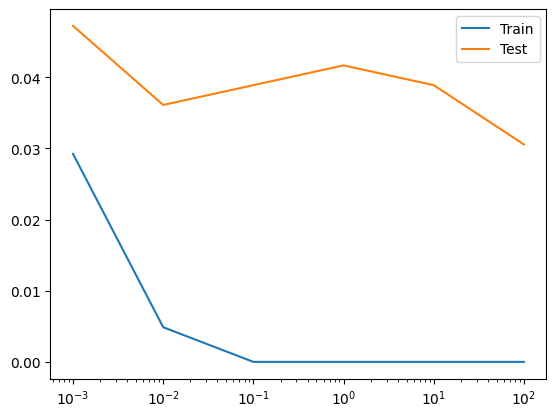

In [7]:
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

data = load_digits()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

train_errs = list()
test_errs = list()

C_values = [0.001, 0.01, 0.1, 1, 10, 100]

for c_value in C_values:
    logreg = LogisticRegression(C=c_value, max_iter=1000)
    logreg.fit(X_train, y_train)
    train_errs.append(1-logreg.score(X_train, y_train))
    test_errs.append(1-logreg.score(X_test, y_test))

plt.semilogx(C_values, train_errs, C_values, test_errs)
plt.legend(["Train", "Test"])
plt.show()

Logistic Regression and Feature Selection

Total Number of Features:  26
Number of selected Features:  15


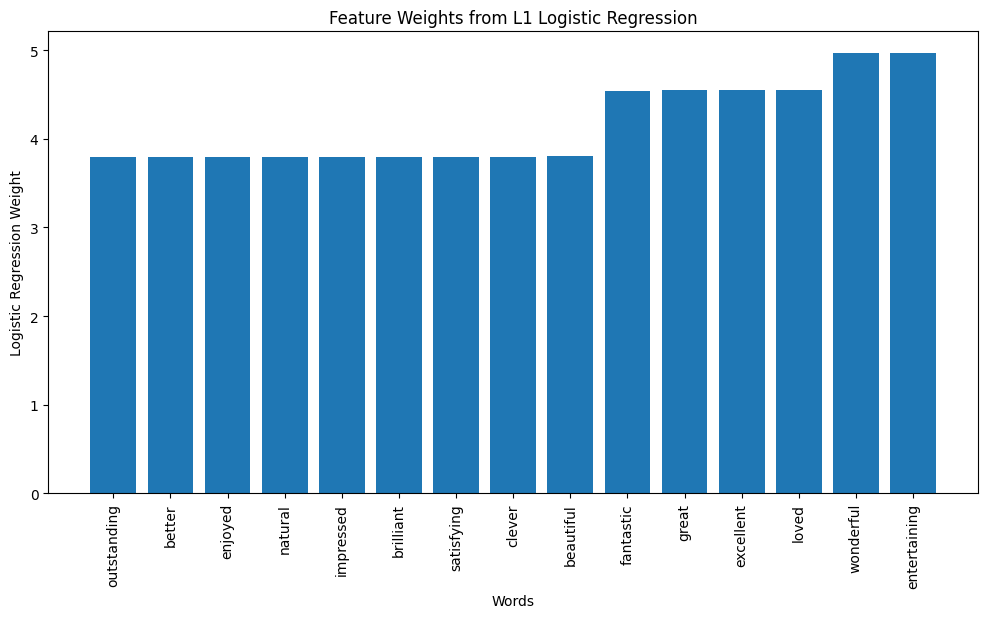

In [ ]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split

df = pd.read_csv("./datasets/reviews.csv")

with open("./datasets/vocabulary.txt", "r") as file:
    vocabulary = file.read().splitlines()

def get_features(reviews):
    features = []
    for review in reviews:
        words = review.lower().split()
        feature = []
        for word in vocabulary:
            if word in words:
                feature.append(1)
            else:
                feature.append(0)
        features.append(feature)
    return features

X = np.array(get_features(df["review"]))
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=41)

lr = LogisticRegression(solver='liblinear', l1_ratio=1)

cv_results = GridSearchCV(lr, {'C':[0.001, 0.01, 0.1, 1, 10]})
cv_results.fit(X_train, y_train)

best_lr = cv_results.best_estimator_
coefs = best_lr.coef_

print("Total Number of Features: ", coefs.size)
print("Number of selected Features: ", np.count_nonzero(coefs))

# visualizing weights
weights = pd.DataFrame({
    "words" : vocabulary,
    "weights" : coefs[0]
})

weights = weights[weights["weights"] != 0]
weights = weights.sort_values("weights")

plt.figure(figsize=(12, 6))

plt.bar(
    weights["words"],
    weights["weights"]
)
plt.xticks(rotation=90)
plt.xlabel("Words")
plt.ylabel("Logistic Regression Weight")
plt.title("Feature Weights from L1 Logistic Regression")


plt.show()

Regularization and Probabilities

In [20]:
import matplotlib.pyplot as plt

def plot_classifier(X, y, model):

    # Create a grid covering the whole dataset
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    # Convert every grid point into [x1, x2]
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Predict the class at every grid point
    predictions = model.predict(grid)

    # Reshape predictions back into the grid
    predictions = predictions.reshape(xx.shape)

    # Draw the background
    plt.contourf(xx, yy, predictions, alpha=0.5)

    # Plot class -1 as circles
    plt.scatter(
        X[y == -1, 0],
        X[y == -1, 1],
        marker="o",
        edgecolor="black"
    )

    # Plot class 1 as triangles
    plt.scatter(
        X[y == 1, 0],
        X[y == 1, 1],
        marker="^",
        edgecolor="black"
    )

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

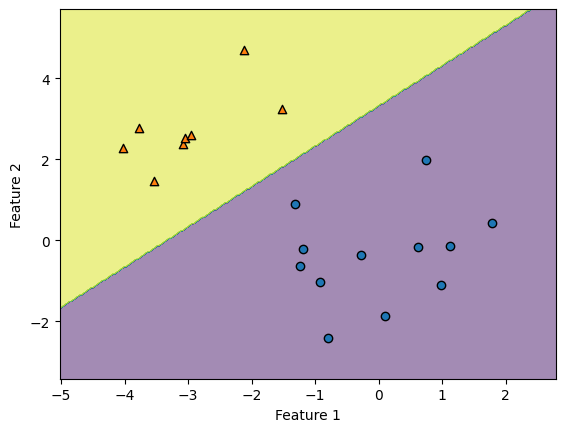

In [22]:
import numpy as np

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(C=0.1)
X = np.array([[ 1.78862847,  0.43650985],
       [ 0.09649747, -1.8634927 ],
       [-0.2773882 , -0.35475898],
       [-3.08274148,  2.37299932],
       [-3.04381817,  2.52278197],
       [-1.31386475,  0.88462238],
       [-2.11868196,  4.70957306],
       [-2.94996636,  2.59532259],
       [-3.54535995,  1.45352268],
       [ 0.98236743, -1.10106763],
       [-1.18504653, -0.2056499 ],
       [-1.51385164,  3.23671627],
       [-4.02378514,  2.2870068 ],
       [ 0.62524497, -0.16051336],
       [-3.76883635,  2.76996928],
       [ 0.74505627,  1.97611078],
       [-1.24412333, -0.62641691],
       [-0.80376609, -2.41908317],
       [-0.92379202, -1.02387576],
       [ 1.12397796, -0.13191423]])

y = np.array([-1, -1, -1,  1,  1, -1,  1,  1,  1, -1, -1,  1,  1, -1,  1, -1, -1,
       -1, -1, -1])

lr.fit(X, y)
plot_classifier(X, y, lr)

Visualizing easy and difficult examples

In [29]:
import matplotlib.pyplot as plt

def show_image(X, index, model):
    plt.imshow(X[index].reshape(8, 8), cmap="gray")
    plt.title(
        f"Predicted: {model.predict(X[index].reshape(1, -1))[0]}"
    )
    plt.axis("off")
    plt.show()

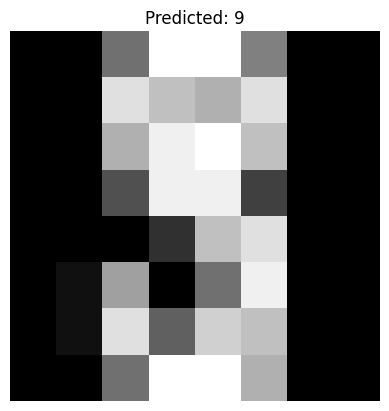

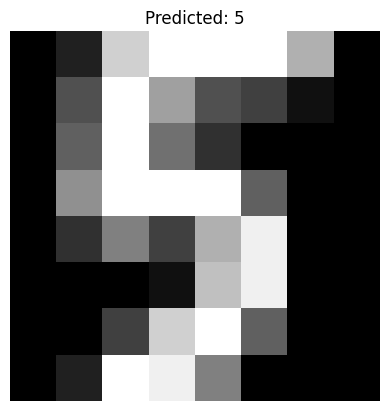

In [30]:
from sklearn.datasets import load_digits
from sklearn.linear_model import LogisticRegression

data = load_digits()
X = data.data
y = data.target

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

proba = model.predict_proba(X)
proba_idx = np.argsort(np.max(proba, axis=1))

# show image with least confidence
show_image(X, proba_idx[0], model)

# show image with most confidence
show_image(X, proba_idx[-1], model)